In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import scipy
import PIL


In [5]:
# Downloade the data file from the https://data.ontario.ca/dataset/5472ffc1-88e2-48ca-bc9f-4aa249c1298d/resource/d5d8f478-765c-4246-b8a7-c3b13a4a1a41/download/outbreak_cases.csv
# Read the data file from local disc

file_path = r"C:\Users\fansh\Downloads\outbreak_cases.csv"

df = pd.read_csv(file_path)

print(df)  # Show the data file


             date     category_grouped              outbreak_subgroup  \
0      2020-03-06  2 Congregate Living                        SHELTER   
1      2020-03-08    1 Congregate Care            LONG-TERM CARE HOME   
2      2020-03-09          4 Workplace              WORKPLACE - OTHER   
3      2020-03-11  2 Congregate Living  GROUP HOME/SUPPORTIVE HOUSING   
4      2020-03-13    1 Congregate Care            LONG-TERM CARE HOME   
...           ...                  ...                            ...   
11674  2023-04-03    1 Congregate Care                RETIREMENT HOME   
11675  2023-04-03  2 Congregate Living  GROUP HOME/SUPPORTIVE HOUSING   
11676  2023-04-04    1 Congregate Care            LONG-TERM CARE HOME   
11677  2023-04-04  2 Congregate Living          CORRECTIONAL FACILITY   
11678  2023-04-04  2 Congregate Living  GROUP HOME/SUPPORTIVE HOUSING   

       TOTAL_CASES  
0                1  
1                1  
2                1  
3                1  
4                1

Subplot - combine different plot onto one 
---Try nesting Seaborn plots into Subplot
    Bar graph of quarterly data
    Scatter plot of quarterly data
    Line plot of monthly data

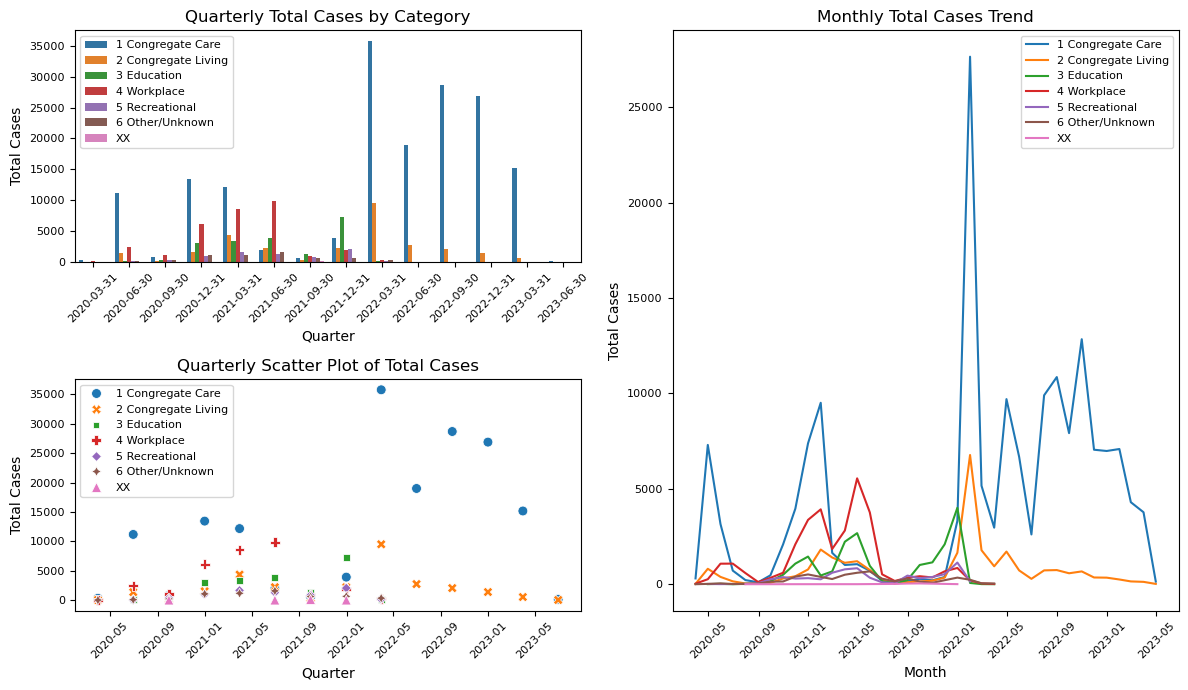

In [74]:
# --- Create subplot mosaic ---
fig, multiplt = plt.subplot_mosaic(
    [['ax1', 'ax3'],  # Row 1: ax1 (bar) on left, ax3 (line) spans right
     ['ax2', 'ax3']],  # Row 2: ax2 (scatter) on left, ax3 continues spanning right
    figsize=(12, 7)
)

# --- 1️⃣ Quarterly Bar Plot (Top-Left) ---
sns.barplot(data=df_quarterly, x='date', y='TOTAL_CASES', hue='category_grouped', ax=multiplt['ax1'])
multiplt['ax1'].set_title("Quarterly Total Cases by Category")
multiplt['ax1'].set_xlabel("Quarter")
multiplt['ax1'].set_ylabel("Total Cases")
multiplt['ax1'].tick_params(axis='x', rotation=45)
multiplt['ax1'].tick_params(axis='both', labelsize=8)
multiplt['ax1'].legend(fontsize=8)

# --- 2️⃣ Quarterly Scatter Plot (Bottom-Left) ---
sns.scatterplot(data=df_quarterly, x='date', y='TOTAL_CASES', hue='category_grouped', style='category_grouped', s=50, ax=multiplt['ax2'])
multiplt['ax2'].set_title("Quarterly Scatter Plot of Total Cases")
multiplt['ax2'].set_xlabel("Quarter")
multiplt['ax2'].set_ylabel("Total Cases")
multiplt['ax2'].tick_params(axis='x', rotation=45)
multiplt['ax2'].tick_params(axis='both', labelsize=8)
multiplt['ax2'].legend(fontsize=8)

# --- 3️⃣ Monthly Line Plot (Right, Spanning Two Rows) ---
sns.lineplot(data=df_monthly, x='date', y='TOTAL_CASES', hue='category_grouped', ax=multiplt['ax3'])
multiplt['ax3'].set_title("Monthly Total Cases Trend")
multiplt['ax3'].set_xlabel("Month")
multiplt['ax3'].set_ylabel("Total Cases")
multiplt['ax3'].tick_params(axis='x', rotation=45)
multiplt['ax3'].tick_params(axis='both', labelsize=8)
multiplt['ax3'].legend(fontsize=8)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()